# GLB → Gemini 2.5 Flash → CoACD → MuJoCo
### Fully Programmatic | No XML | No pyrender

**Run order:**
1. Run **Step 1** (installs packages + auto-restarts kernel)
2. After restart, run **Steps 2–11** (Runtime → Run after)


In [ ]:
# STEP 1: Install all packages then auto-restart kernel
# Colab requires a restart for newly installed packages to be importable.
# This cell handles that automatically — just wait for it to finish.

import subprocess, sys

pkgs = [
    'trimesh==4.5.3',
    'coacd==1.0.7',
    'mujoco==3.2.7',
    'google-genai',
    'pygltflib',
    'Pillow',
    'numpy',
    'scipy',
    'matplotlib',
]

for pkg in pkgs:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('\n✅ All packages installed — restarting kernel now...')
import os
os.kill(os.getpid(), 9)  # hard restart — Colab will show 'Your session crashed'
                          # That is expected. Just continue from Step 2.


Installing trimesh==4.5.3...
Installing coacd==1.0.7...
Installing mujoco==3.2.7...
Installing google-genai...
Installing pygltflib...
Installing Pillow...
Installing numpy...
Installing scipy...
Installing matplotlib...


In [1]:
# STEP 2: Imports + verify versions (run AFTER kernel restart from Step 1)
import os, json, zipfile
import numpy as np

# MUST be set before import mujoco — MuJoCo reads this at import time
os.environ['MUJOCO_GL'] = 'egl'
import subprocess
subprocess.run(['apt-get','install','-qq','-y',
                'libegl1-mesa-dev','libgles2-mesa-dev'], capture_output=True)

import trimesh
import coacd
import mujoco
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image
from pathlib import Path
from io import BytesIO
from importlib.metadata import version as pkg_version
from IPython.display import display, Image as IPImage
from google import genai
from google.genai import types

print(f'trimesh : {trimesh.__version__}')
print(f'coacd   : {pkg_version("coacd")}')
print(f'mujoco  : {mujoco.__version__}')
print(f'genai   : {pkg_version("google-genai")}')

GEMINI_API_KEY = 'YOUR_API_KEY_HERE'
client = genai.Client(api_key=GEMINI_API_KEY)

OUT = Path('/content/output')
OUT.mkdir(exist_ok=True)
print('✅ Imports done')

trimesh : 4.5.3
coacd   : 1.0.7
mujoco  : 3.2.7
genai   : 1.66.0
✅ Imports done


In [2]:
# STEP 2: Imports + verify versions (run AFTER kernel restart from Step 1)
import os, json, zipfile
import numpy as np
import trimesh
import coacd
import mujoco
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image
from pathlib import Path
from io import BytesIO
from importlib.metadata import version as pkg_version
from IPython.display import display, Image as IPImage
from google import genai
from google.genai import types

print(f'trimesh : {trimesh.__version__}')
print(f'coacd   : {pkg_version("coacd")}')
print(f'mujoco  : {mujoco.__version__}')
print(f'genai   : {pkg_version("google-genai")}')

GEMINI_API_KEY = 'YOUR_API_KEY_HERE'
client = genai.Client(api_key=GEMINI_API_KEY)

OUT = Path('/content/output')
OUT.mkdir(exist_ok=True)
print('✅ Imports done')


trimesh : 4.5.3
coacd   : 1.0.7
mujoco  : 3.2.7
genai   : 1.66.0
✅ Imports done


In [3]:
# STEP 3: Upload GLB
from google.colab import files
print('📂 Upload your .glb or .obj file:')
uploaded   = files.upload()
filename   = list(uploaded.keys())[0]
INPUT_PATH = Path(f'/content/{filename}')
with open(INPUT_PATH, 'wb') as f:
    f.write(uploaded[filename])
print(f'✅ {INPUT_PATH}  ({INPUT_PATH.stat().st_size/1024:.1f} KB)')


📂 Upload your .glb or .obj file:


Saving object_5.glb to object_5.glb
✅ /content/object_5.glb  (1610.9 KB)


In [4]:
# STEP 4: Load mesh — all coordinates come directly from file, never set manually
def load_mesh(path):
    loaded = trimesh.load(str(path), force='mesh')
    if isinstance(loaded, trimesh.Scene):
        meshes = [g for g in loaded.geometry.values() if isinstance(g, trimesh.Trimesh)]
        mesh   = trimesh.util.concatenate(meshes)
    else:
        mesh = loaded
    mesh.process(validate=True)
    mesh.fill_holes()
    print(f'  Vertices   : {len(mesh.vertices):,}')
    print(f'  Faces      : {len(mesh.faces):,}')
    print(f'  Watertight : {mesh.is_watertight}')
    print(f'  Bounds     :\n{np.round(mesh.bounds, 4)}')
    return mesh

mesh = load_mesh(INPUT_PATH)
print('✅ Mesh loaded')


  Vertices   : 13,693
  Faces      : 20,977
  Watertight : False
  Bounds     :
[[-0.3865 -0.4998 -0.3551]
 [ 0.3896  0.4998  0.3502]]
✅ Mesh loaded


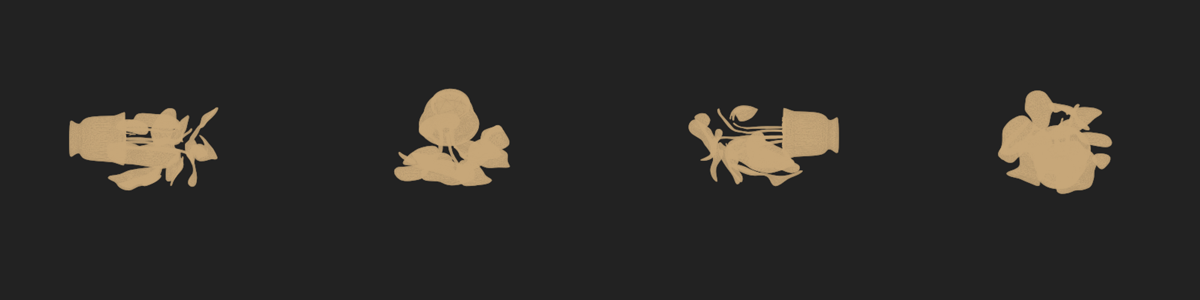

✅ 4 views rendered


In [5]:
# STEP 5: Render 4 views with matplotlib (no OpenGL, no pyrender, no OSMesa needed)
def render_views(mesh, n=4):
    v = mesh.vertices.copy()
    v -= v.mean(axis=0)
    v /= np.abs(v).max()
    f = mesh.faces
    images = []
    for az in np.linspace(0, 360, n, endpoint=False):
        fig = plt.figure(figsize=(5, 5), facecolor='#222222')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#222222')
        ax.add_collection3d(Poly3DCollection(v[f], alpha=0.92,
                            linewidths=0, facecolors='#c8a87a', edgecolors='none'))
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)
        ax.set_axis_off()
        ax.view_init(elev=25, azim=az)
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=100, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.close(fig)
        buf.seek(0)
        images.append(Image.open(buf).convert('RGB').copy())
    return images

views = render_views(mesh)
for i, v in enumerate(views): v.save(OUT/f'view_{i}.png')
row = Image.new('RGB', (500*4, 500))
for i, img in enumerate(views): row.paste(img.resize((500,500)), (500*i,0))
display(row.resize((1200, 300)))
print('✅ 4 views rendered')


In [6]:
# STEP 6: Gemini 2.5 Flash — infer mass, friction, restitution, material
import re

PROMPT = """You are a physics property estimator for a simulation engine.
Given 4 rendered views of a 3D object, return ONLY this JSON and nothing else.
No thinking. No explanation. No markdown. Start your response with { and end with }

{
  "object_name": "<short name>",
  "material": "<ceramic|wood|metal|plastic|rubber|glass|fabric|stone>",
  "mass_kg": <float>,
  "friction": <float 0.0-1.0>,
  "restitution": <float 0.0-1.0>,
  "reasoning": "<one sentence>"
}"""

def pil_to_part(img):
    buf = BytesIO()
    img.save(buf, format='PNG')
    return types.Part.from_bytes(data=buf.getvalue(), mime_type='image/png')

contents = [types.Part.from_text(text=PROMPT)] + [pil_to_part(v) for v in views]
resp = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=contents,
    config=types.GenerateContentConfig(
        temperature=0.0,
        max_output_tokens=2048   # was 512 — too small, response was getting cut mid-string
    )
)

raw = resp.text.strip()
print('── Raw Gemini response ──────────────────────────')
print(raw)
print('────────────────────────────────────────────────')

# Greedy match: r'\{.*\}' not r'\{.*?\}'
# Non-greedy stops at FIRST closing brace — wrong for nested JSON
match = re.search(r'\{.*\}', raw, re.DOTALL)
if not match:
    raise ValueError(f'No JSON object found:\n{raw}')

props = json.loads(match.group())
with open(OUT/'physics_properties.json','w') as f: json.dump(props,f,indent=2)
print('\n── Gemini Physics Tags ──────────────────────────')
for k,val in props.items(): print(f'  {k:15s}: {val}')
print('✅ VLM tagging done')

── Raw Gemini response ──────────────────────────
{
  "object_name": "ceramic vase with plants",
  "material": "ceramic",
  "mass_kg": 1.5,
  "friction": 0.7,
  "restitution": 0.3,
  "reasoning": "The object appears to be a ceramic vase with plant elements, suggesting a moderate mass and typical ceramic properties for friction and restitution."
}
────────────────────────────────────────────────

── Gemini Physics Tags ──────────────────────────
  object_name    : ceramic vase with plants
  material       : ceramic
  mass_kg        : 1.5
  friction       : 0.7
  restitution    : 0.3
  reasoning      : The object appears to be a ceramic vase with plant elements, suggesting a moderate mass and typical ceramic properties for friction and restitution.
✅ VLM tagging done


In [7]:
# STEP 7: CoACD convex decomposition → collision hulls
# Actual API: run_coacd(mesh, threshold, max_convex_hull, preprocess_mode, resolution, ...)
# preprocess_mode = "auto" | "on" | "off"   — NOT a bool called 'preprocess'
# NO 'merge' parameter exists in the Python API

cm    = coacd.Mesh(mesh.vertices, mesh.faces)
parts = coacd.run_coacd(
    cm,
    threshold       = 0.05,
    max_convex_hull = 32,
    preprocess_mode = "auto"   # "auto" works best for manifold meshes
)

hulls = []
for i, (v, f) in enumerate(parts):
    h = trimesh.Trimesh(vertices=np.array(v), faces=np.array(f))
    p = OUT / f'hull_{i:02d}.obj'
    h.export(str(p))
    hulls.append((h, p))
    print(f'  hull_{i:02d}: {len(h.vertices)} verts  vol={h.volume:.6f}')

print(f'✅ {len(hulls)} hull(s) generated')

  hull_00: 316 verts  vol=0.001725
  hull_01: 339 verts  vol=0.000622
  hull_02: 332 verts  vol=0.001642
  hull_03: 346 verts  vol=0.002745
  hull_04: 140 verts  vol=0.000203
  hull_05: 129 verts  vol=0.000531
  hull_06: 274 verts  vol=0.001937
  hull_07: 270 verts  vol=0.000820
  hull_08: 219 verts  vol=0.000383
  hull_09: 88 verts  vol=0.001954
  hull_10: 930 verts  vol=0.011980
  hull_11: 93 verts  vol=0.000393
  hull_12: 268 verts  vol=0.003164
  hull_13: 475 verts  vol=0.002672
  hull_14: 137 verts  vol=0.000217
  hull_15: 301 verts  vol=0.002481
  hull_16: 1625 verts  vol=0.030170
  hull_17: 264 verts  vol=0.002658
  hull_18: 399 verts  vol=0.002972
  hull_19: 303 verts  vol=0.000505
  hull_20: 124 verts  vol=0.001036
  hull_21: 228 verts  vol=0.000291
  hull_22: 211 verts  vol=0.002094
  hull_23: 99 verts  vol=0.000283
  hull_24: 412 verts  vol=0.000484
  hull_25: 162 verts  vol=0.000395
  hull_26: 427 verts  vol=0.001593
  hull_27: 296 verts  vol=0.001628
  hull_28: 142 verts  

In [8]:
# STEP 8: MuJoCo — from_xml_string + assets dict
assets = {}

vis_path = OUT/'visual.obj'
mesh.export(str(vis_path))
assets['visual.obj'] = vis_path.read_bytes()

hull_names = []
for i,(h,_) in enumerate(hulls):
    nm = f'hull_{i:02d}'
    hp = OUT/f'{nm}.obj'
    assets[f'{nm}.obj'] = hp.read_bytes()
    hull_names.append(nm)

spawn_z   = float(0.5 - mesh.bounds[0][2])
mass      = float(props['mass_kg'])
fric      = float(props['friction'])
total_vol = sum(h.volume for h,_ in hulls) or 1.0

mesh_assets = '\n'.join(
    ['<mesh name="vis_mesh" file="visual.obj"/>'] +
    [f'<mesh name="{nm}" file="{nm}.obj"/>' for nm in hull_names]
)

col_geoms = '\n'.join(
    f'<geom name="col_{i:02d}" type="mesh" mesh="{nm}" '
    f'mass="{mass*(hulls[i][0].volume/total_vol):.6f}" '
    f'friction="{fric} 0.005 0.0001" rgba="0 0 0 0"/>'
    for i,nm in enumerate(hull_names)
)

xml = f"""
<mujoco model="{props['object_name'].replace(' ','_')}">
  <compiler angle="radian"/>
  <option gravity="0 0 -9.81" timestep="0.002" integrator="implicitfast"/>
  <asset>
    {mesh_assets}
  </asset>
  <worldbody>
    <light pos="0 0 4" dir="0 0 -1" castshadow="true"/>
    <geom name="floor" type="plane" size="10 10 0.1"
          friction="{fric} 0.005 0.0001" rgba="0.7 0.7 0.7 1"/>
    <body name="object" pos="0 0 {spawn_z:.6f}">
      <freejoint/>
      <geom name="visual" type="mesh" mesh="vis_mesh"
            contype="0" conaffinity="0" rgba="0.9 0.8 0.65 1"/>
      {col_geoms}
    </body>
  </worldbody>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(xml, assets)
data  = mujoco.MjData(model)
print(f'✅ Compiled — {model.nbody} bodies | {model.ngeom} geoms | {model.nv} DoF')
print(f'   mass={mass}kg  friction={fric}  spawn_z={spawn_z:.4f}')

✅ Compiled — 2 bodies | 34 geoms | 6 DoF
   mass=1.5kg  friction=0.7  spawn_z=0.8551


In [9]:
# STEP 9: Simulate 3 seconds + capture frames
renderer = mujoco.Renderer(model, height=480, width=640)
cam=mujoco.MjvCamera()
cam.type=mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat=[0,0,0.3]; cam.distance=2.0; cam.elevation=-25; cam.azimuth=45
opt=mujoco.MjvOption(); mujoco.mjv_defaultOption(opt)

duration=3.0
skip  = max(1,int(1.0/(30*model.opt.timestep)))
steps = int(duration/model.opt.timestep)
frames= []
print(f'Simulating {duration}s ({steps:,} steps)...')
for s in range(steps):
    mujoco.mj_step(model,data)
    if s%skip==0:
        renderer.update_scene(data,camera=cam,scene_option=opt)
        frames.append(renderer.render().copy())
    if s%10000==0:
        print(f'  t={data.time:.2f}s | z={data.qpos[2]:.4f}m | contacts={data.ncon}')
renderer.close()
print(f'✅ {len(frames)} frames captured')


Simulating 3.0s (1,500 steps)...
  t=0.00s | z=0.8550m | contacts=0
✅ 94 frames captured


In [10]:
# STEP 9: Simulate + capture frames
# Fix: tell MuJoCo to use EGL (headless OpenGL) — must be set before Renderer init
import os
os.environ['MUJOCO_GL'] = 'egl'

# EGL libs for Colab
import subprocess
subprocess.run(['apt-get', 'install', '-qq', '-y',
                'libegl1-mesa-dev', 'libgles2-mesa-dev'],
               capture_output=True)

renderer = mujoco.Renderer(model, height=480, width=640)
cam = mujoco.MjvCamera()
cam.type      = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat    = [0, 0, 0.3]
cam.distance  = 2.0
cam.elevation = -25
cam.azimuth   = 45
opt = mujoco.MjvOption()
mujoco.mjv_defaultOption(opt)

duration = 3.0
skip   = max(1, int(1.0 / (30 * model.opt.timestep)))
steps  = int(duration / model.opt.timestep)
frames = []

print(f'Simulating {duration}s ({steps:,} steps)...')
for s in range(steps):
    mujoco.mj_step(model, data)
    if s % skip == 0:
        renderer.update_scene(data, camera=cam, scene_option=opt)
        frames.append(renderer.render().copy())
    if s % 10000 == 0:
        print(f'  t={data.time:.2f}s | z={data.qpos[2]:.4f}m | contacts={data.ncon}')

renderer.close()
print(f'✅ {len(frames)} frames captured')

Simulating 3.0s (1,500 steps)...
  t=3.00s | z=0.3185m | contacts=3
✅ 94 frames captured


✅ /content/output/simulation.gif


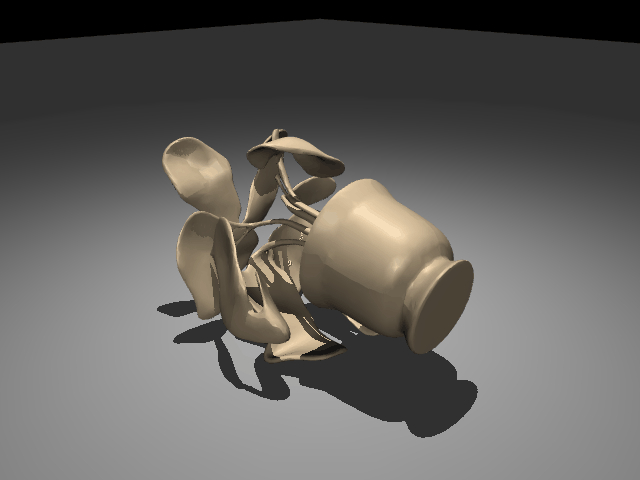


── Physics Summary ──────────────────────────
  object_name    : ceramic vase with plants
  material       : ceramic
  mass_kg        : 1.5
  friction       : 0.7
  restitution    : 0.3
  reasoning      : The object appears to be a ceramic vase with plant elements, suggesting a moderate mass and typical ceramic properties for friction and restitution.


In [11]:
# STEP 10: Save GIF + display
gif = OUT/'simulation.gif'
pf  = [Image.fromarray(f) for f in frames]
pf[0].save(str(gif),save_all=True,append_images=pf[1:],duration=int(1000/30),loop=0)
print(f'✅ {gif}')
display(IPImage(filename=str(gif)))
print('\n── Physics Summary ──────────────────────────')
for k,val in props.items(): print(f'  {k:15s}: {val}')


In [12]:
# STEP 11: Zip all outputs + download
from google.colab import files as colab_files
zip_path='/content/output.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for f in OUT.iterdir(): z.write(f,arcname=f.name)
print('📦 Contents:')
with zipfile.ZipFile(zip_path) as z:
    for n in sorted(z.namelist()):
        print(f'   {n:30s}  {z.getinfo(n).file_size/1024:6.1f} KB')
colab_files.download(zip_path)
print('✅ Download started')


📦 Contents:
   hull_00.obj                       19.7 KB
   hull_01.obj                       20.2 KB
   hull_02.obj                       20.0 KB
   hull_03.obj                       21.2 KB
   hull_04.obj                        7.9 KB
   hull_05.obj                        7.6 KB
   hull_06.obj                       16.7 KB
   hull_07.obj                       16.5 KB
   hull_08.obj                       13.3 KB
   hull_09.obj                        4.9 KB
   hull_10.obj                       58.1 KB
   hull_11.obj                        5.2 KB
   hull_12.obj                       16.3 KB
   hull_13.obj                       29.5 KB
   hull_14.obj                        7.9 KB
   hull_15.obj                       18.3 KB
   hull_16.obj                      105.2 KB
   hull_17.obj                       15.8 KB
   hull_18.obj                       24.4 KB
   hull_19.obj                       18.5 KB
   hull_20.obj                        7.2 KB
   hull_21.obj                       13.5 K

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started


In [13]:
# STEP 11: Zip all outputs + download
from google.colab import files as colab_files
zip_path = '/content/output.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in OUT.rglob('*'):        # rglob instead of iterdir — includes subdirectories
        if f.is_file():
            z.write(f, arcname=f.relative_to(OUT))
print('📦 Contents:')
with zipfile.ZipFile(zip_path) as z:
    for n in sorted(z.namelist()):
        print(f'   {n}')
colab_files.download(zip_path)
print('✅ Download started')

📦 Contents:
   hull_00.obj
   hull_01.obj
   hull_02.obj
   hull_03.obj
   hull_04.obj
   hull_05.obj
   hull_06.obj
   hull_07.obj
   hull_08.obj
   hull_09.obj
   hull_10.obj
   hull_11.obj
   hull_12.obj
   hull_13.obj
   hull_14.obj
   hull_15.obj
   hull_16.obj
   hull_17.obj
   hull_18.obj
   hull_19.obj
   hull_20.obj
   hull_21.obj
   hull_22.obj
   hull_23.obj
   hull_24.obj
   hull_25.obj
   hull_26.obj
   hull_27.obj
   hull_28.obj
   hull_29.obj
   hull_30.obj
   hull_31.obj
   material.mtl
   material_0.png
   physics_properties.json
   simulation.gif
   view_0.png
   view_1.png
   view_2.png
   view_3.png
   visual.obj


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started


In [14]:
# Save the XML so you can load it locally
with open(OUT/'scene.xml', 'w') as f:
    f.write(xml)
print('✅ scene.xml saved')

✅ scene.xml saved
